# Übung 2
**Mustererkennung und Maschinelles Lernen - SS 2026**

Dieses Notebook enthält die Imports, Random-Seeds und die Datenerzeugung für alle Aufgaben.
Nutzen Sie dieses Gerüst für Ihre eigenen Lösungen.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, confusion_matrix

RNG = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (8, 5)

---
## Daten für Aufgabe 1 — Polynomielle Regression

Trainings- und Testdatensatz aus `sin(2πx) + ε`, mit `ε ~ N(0, 0.3²)`.

In [3]:
def true_function(x):
    return np.sin(2 * np.pi * x)

def generate_dataset(n, rng, noise_std=0.3):
    x = rng.uniform(0, 1, size=n)
    x.sort()
    t = true_function(x) + rng.normal(0, noise_std, size=n)
    return x, t

rng_train = np.random.default_rng(seed=1)
rng_test  = np.random.default_rng(seed=2)

x_train, t_train = generate_dataset(n=10,  rng=rng_train)
x_test,  t_test  = generate_dataset(n=100, rng=rng_test)

# Derselbe Erzeugungsprozess, aber mit N=100
rng_train_big = np.random.default_rng(seed=3)
x_train_big, t_train_big = generate_dataset(n=100, rng=rng_train_big)

print(f'Trainingsdaten:             {x_train.shape}')
print(f'Testdaten:                  {x_test.shape}')
print(f'Trainingsdaten (groß):      {x_train_big.shape}')

Trainingsdaten:             (10,)
Testdaten:                  (100,)
Trainingsdaten (groß):      (100,)


## Aufgabe 1 — Ihre Lösung

*(a) Plotten Sie die beiden Datensätze gemeinsam mit der wahren Funktion.*

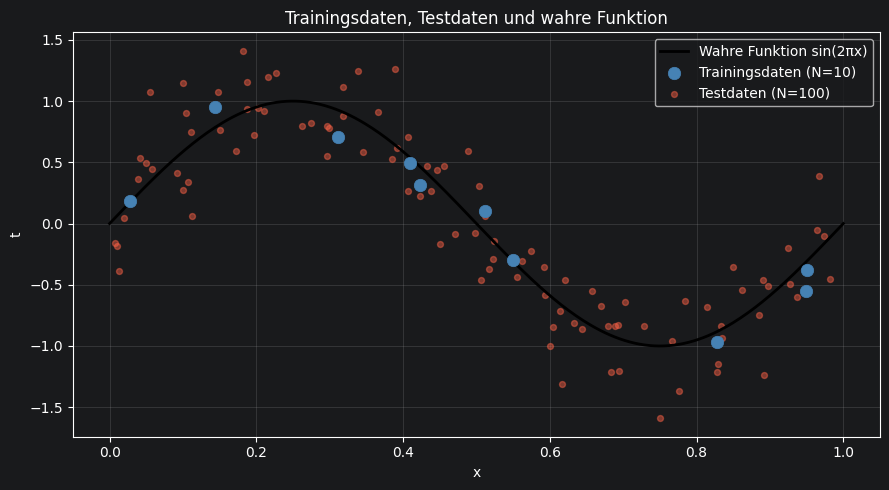

In [4]:
x_true = np.linspace(0, 1, 300)
y_true = true_function(x_true)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_true, y_true, 'k-', linewidth=2, label='Wahre Funktion sin(2πx)', zorder=3)
ax.scatter(x_train, t_train, color='steelblue', s=80, zorder=5,
           label=f'Trainingsdaten (N={len(x_train)})', linewidths=0.5)
ax.scatter(x_test, t_test, color='tomato', alpha=0.45, s=18, zorder=2,
           label=f'Testdaten (N={len(x_test)})')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Trainingsdaten, Testdaten und wahre Funktion')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

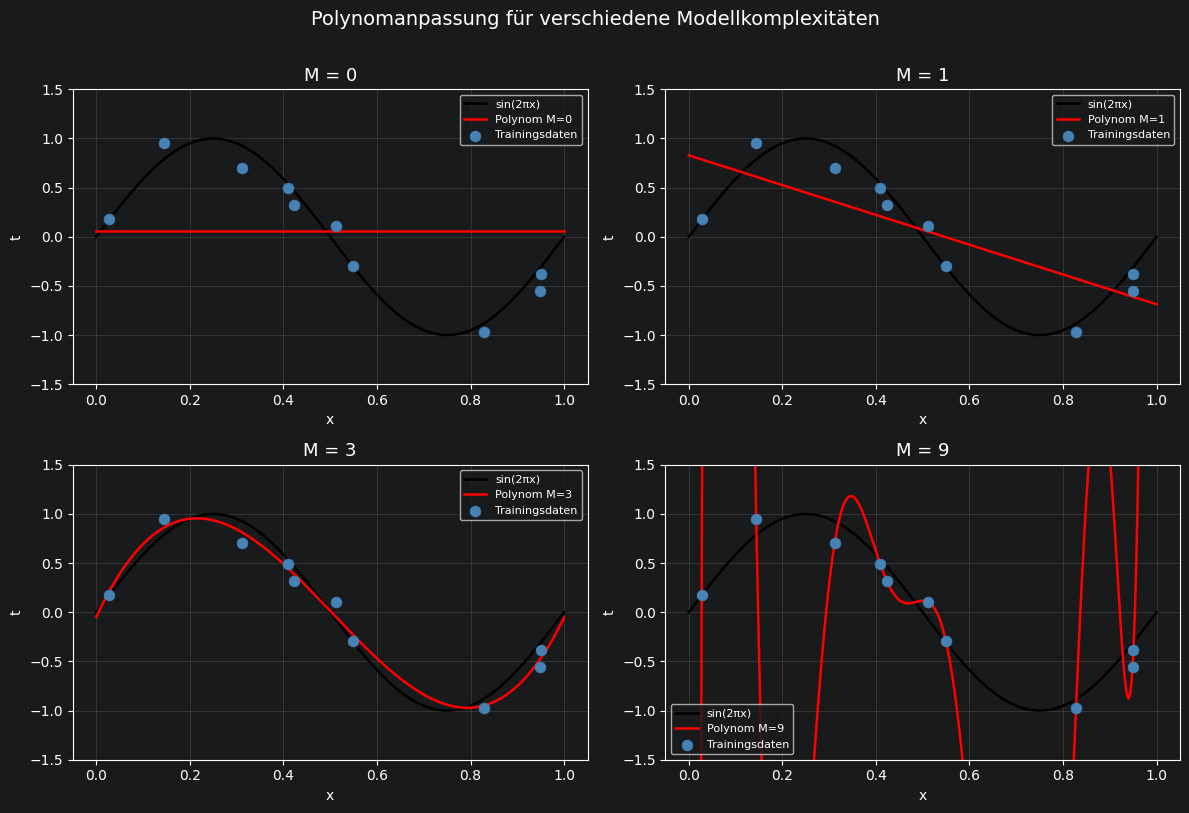

In [5]:
degrees = [0, 1, 3, 9]

x_true = np.linspace(0, 1, 300)
y_true = true_function(x_true)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, M in zip(axes, degrees):
    # Polynom anpassen
    coeffs = np.polyfit(x_train, t_train, deg=M)
    y_fit  = np.polyval(coeffs, x_true)

    ax.plot(x_true, y_true, 'k-',  linewidth=1.8, label='sin(2πx)')
    ax.plot(x_true, y_fit,  'r-',  linewidth=1.8, label=f'Polynom M={M}')
    ax.scatter(x_train, t_train, color='steelblue', s=60, zorder=5, linewidths=0.5, label='Trainingsdaten')

    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'M = {M}', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

fig.suptitle('Polynomanpassung für verschiedene Modellkomplexitäten', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

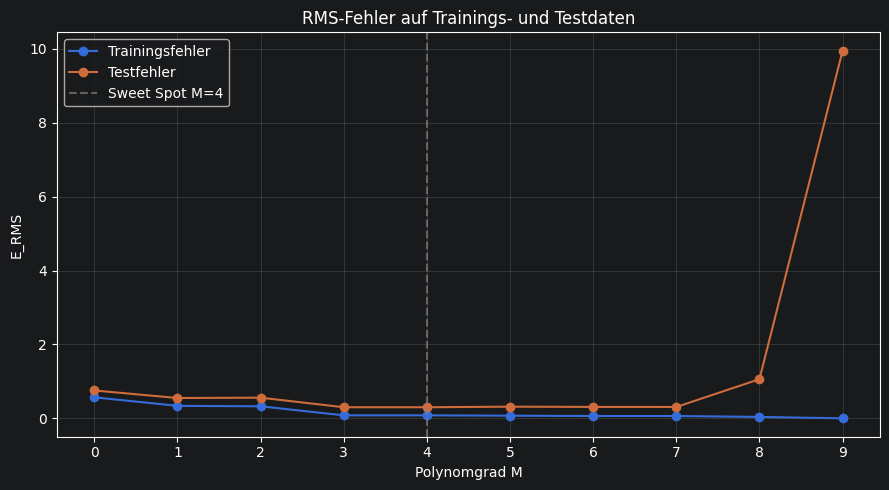

Sweet Spot: M = 4  →  Test-RMS = 0.3006


In [6]:
degrees = list(range(10))  # 0 -9
rms_train = []
rms_test  = []

for M in degrees:
    # Polynom anpassen
    coeffs = np.polyfit(x_train, t_train, deg=M)

    # Vorhersagen auf Trainings- und Testdaten
    y_pred_train = np.polyval(coeffs, x_train)
    y_pred_test  = np.polyval(coeffs, x_test)

    # RMS-Fehler
    rms_train.append(np.sqrt(np.mean((y_pred_train - t_train)**2)))
    rms_test.append( np.sqrt(np.mean((y_pred_test  - t_test )**2)))

# Plot
plt.figure(figsize=(9, 5))
plt.plot(degrees, rms_train, 'o-',  label='Trainingsfehler')
plt.plot(degrees, rms_test,  'o-',  label='Testfehler')

# Sweet Spot
best_M = int(np.argmin(rms_test))
plt.axvline(best_M, color='gray', linestyle='--', alpha=0.7,
            label=f'Sweet Spot M={best_M}')

plt.xlabel('Polynomgrad M')
plt.ylabel('E_RMS')
plt.title('RMS-Fehler auf Trainings- und Testdaten')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Sweet Spot: M = {best_M}  →  Test-RMS = {rms_test[best_M]:.4f}")

C:\Users\toyel\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.778151694288775e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


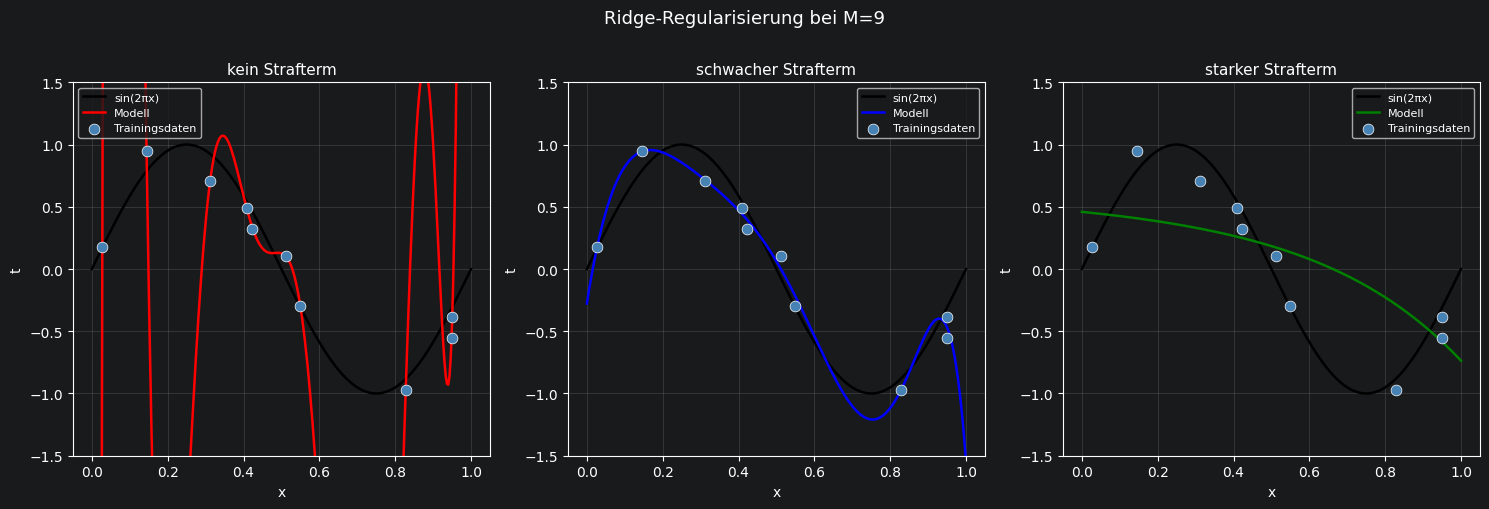

    kein Strafterm  schwacher Strafterm  starker Strafterm
w0        -63.9539              -0.2771            +0.4595
w1      +3590.3524             +19.4548            -0.3064
w2     -55911.8711            -105.9616            -0.3101
w3    +408825.2616            +232.4232            -0.2371
w4   -1677189.1544            -166.6584            -0.1650
w5   +4158088.3181            -121.0707            -0.1067
w6   -6362863.6952             +85.0387            -0.0616
w7   +5872411.1075            +132.7693            -0.0272
w8   -2993659.5443             +17.3050            -0.0010
w9    +646805.6531             -94.5662            +0.0190


In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

M = 9
lambdas = [0, np.exp(-18), 1]
labels  = ['kein Strafterm', 'schwacher Strafterm', 'starker Strafterm']
colors  = ['red', 'blue', 'green']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
all_coeffs = []

for ax, lam, label, color in zip(axes, lambdas, labels, colors):
    # Pipeline: Polynomfeatures + Ridge
    model = make_pipeline(
        PolynomialFeatures(degree=M, include_bias=False),
        Ridge(alpha=lam)
    )
    model.fit(x_train.reshape(-1, 1), t_train)

    # Koeffizienten speichern (+ Intercept)
    ridge = model.named_steps['ridge']
    all_coeffs.append(np.concatenate([[ridge.intercept_], ridge.coef_]))

    # Vorhersage
    y_pred = model.predict(x_true.reshape(-1, 1))

    ax.plot(x_true, y_true,  'k-',  linewidth=1.8, label='sin(2πx)')
    ax.plot(x_true, y_pred,  '-',   linewidth=1.8, color=color, label='Modell')
    ax.scatter(x_train, t_train, color='steelblue', s=60, zorder=5,
               edgecolors='white', linewidths=0.5, label='Trainingsdaten')

    ax.set_ylim(-1.5, 1.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Ridge-Regularisierung bei M=9', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#Koeffizienten-Tabelle
coeff_names = [f'w{i}' for i in range(0, M+1)]
df = pd.DataFrame(
    np.array(all_coeffs).T,
    index=coeff_names,
    columns=labels
)
print(df.to_string(float_format=lambda x: f'{x:+.4f}'))

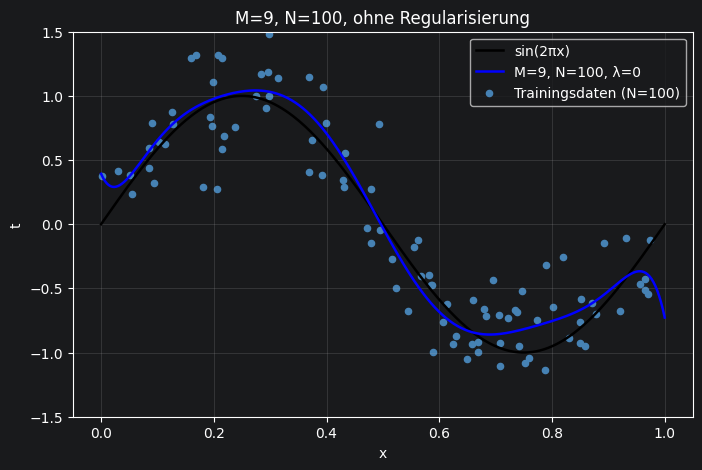

In [8]:
M = 9

x_true = np.linspace(0, 1, 300)
y_true = true_function(x_true)

coeffs_big = np.polyfit(x_train_big, t_train_big, deg=M)
y_big      = np.polyval(coeffs_big, x_true)

plt.figure(figsize=(8, 5))
plt.plot(x_true, y_true, 'k-',  linewidth=1.8, label='sin(2πx)')
plt.plot(x_true, y_big,  'b-',  linewidth=1.8, label='M=9, N=100, λ=0')
plt.scatter(x_train_big, t_train_big, color='steelblue', s=20,label='Trainingsdaten (N=100)')
plt.ylim(-1.5, 1.5)
plt.xlabel('x')
plt.ylabel('t')
plt.title('M=9, N=100, ohne Regularisierung')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---
## Daten für Aufgabe 2 — Wine-Datensatz

In [9]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
feature_names = wine.feature_names
class_names = list(wine.target_names)

print(f'Form von X:    {X_wine.shape}')
print(f'Klassen:       {class_names}')
print(f'Klassenanzahl: {np.bincount(y_wine)}')

Form von X:    (178, 13)
Klassen:       [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Klassenanzahl: [59 71 48]


## Aufgabe 2 — Ihre Lösung

In [10]:
df = pd.DataFrame(X_wine, columns=feature_names)
df["class"] = [class_names[i] for i in y_wine]

print("Klassennamen:  ", class_names)
print("Featurenamen:  ", feature_names)
print()

# Klassenverteilung
counts = np.bincount(y_wine)
for i, (name, count) in enumerate(zip(class_names, counts)):
    print(f"  Klasse {i} ({name}): {count} Samples")

df_mean = df.groupby("class")[["alcohol", "flavanoids", "color_intensity"]].mean().round(3)
df_mean

Klassennamen:   [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Featurenamen:   ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

  Klasse 0 (class_0): 59 Samples
  Klasse 1 (class_1): 71 Samples
  Klasse 2 (class_2): 48 Samples


,alcohol,flavanoids,color_intensity
class,,,
class_0,13.745,2.982,5.528
class_1,12.279,2.081,3.087
class_2,13.154,0.781,7.396


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Train/Test-Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, stratify=y_wine, random_state=42
)

# Baseline Decision Tree mit Default-Parametern
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Ergebnisse
print(f"Test-Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Baumtiefe     : {clf.get_depth()}")
print()

# Confusion Matrix als DataFrame
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
df_cm = pd.DataFrame(
    cm,
    index=[f"Actual: {n}" for n in class_names],
    columns=[f"Predicted: {n}" for n in class_names]
)
print("Confusion Matrix:")
df_cm

Test-Accuracy : 0.9630
Baumtiefe     : 4

Confusion Matrix:


,Predicted: class_0,Predicted: class_1,Predicted: class_2
Actual: class_0,17,1,0
Actual: class_1,0,21,0
Actual: class_2,0,1,14


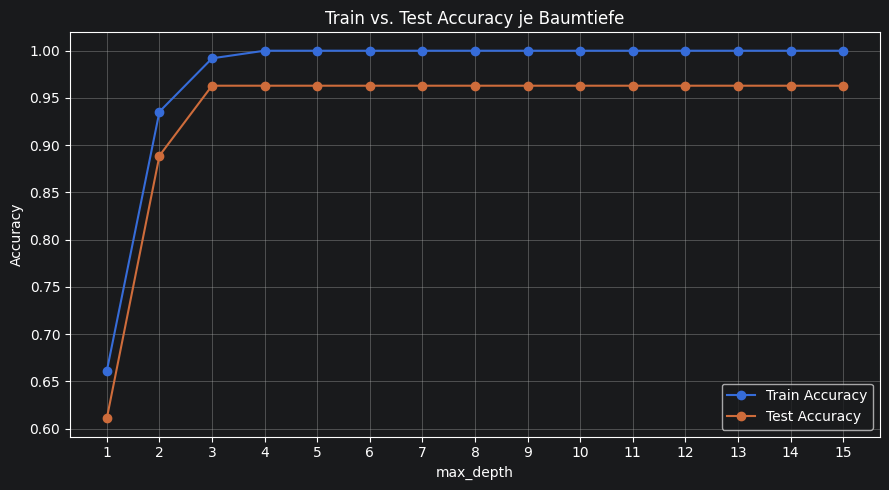

In [12]:
import matplotlib.pyplot as plt

depths = range(1, 16)
train_acc = []
test_acc  = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  tree.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc,  marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy je Baumtiefe")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

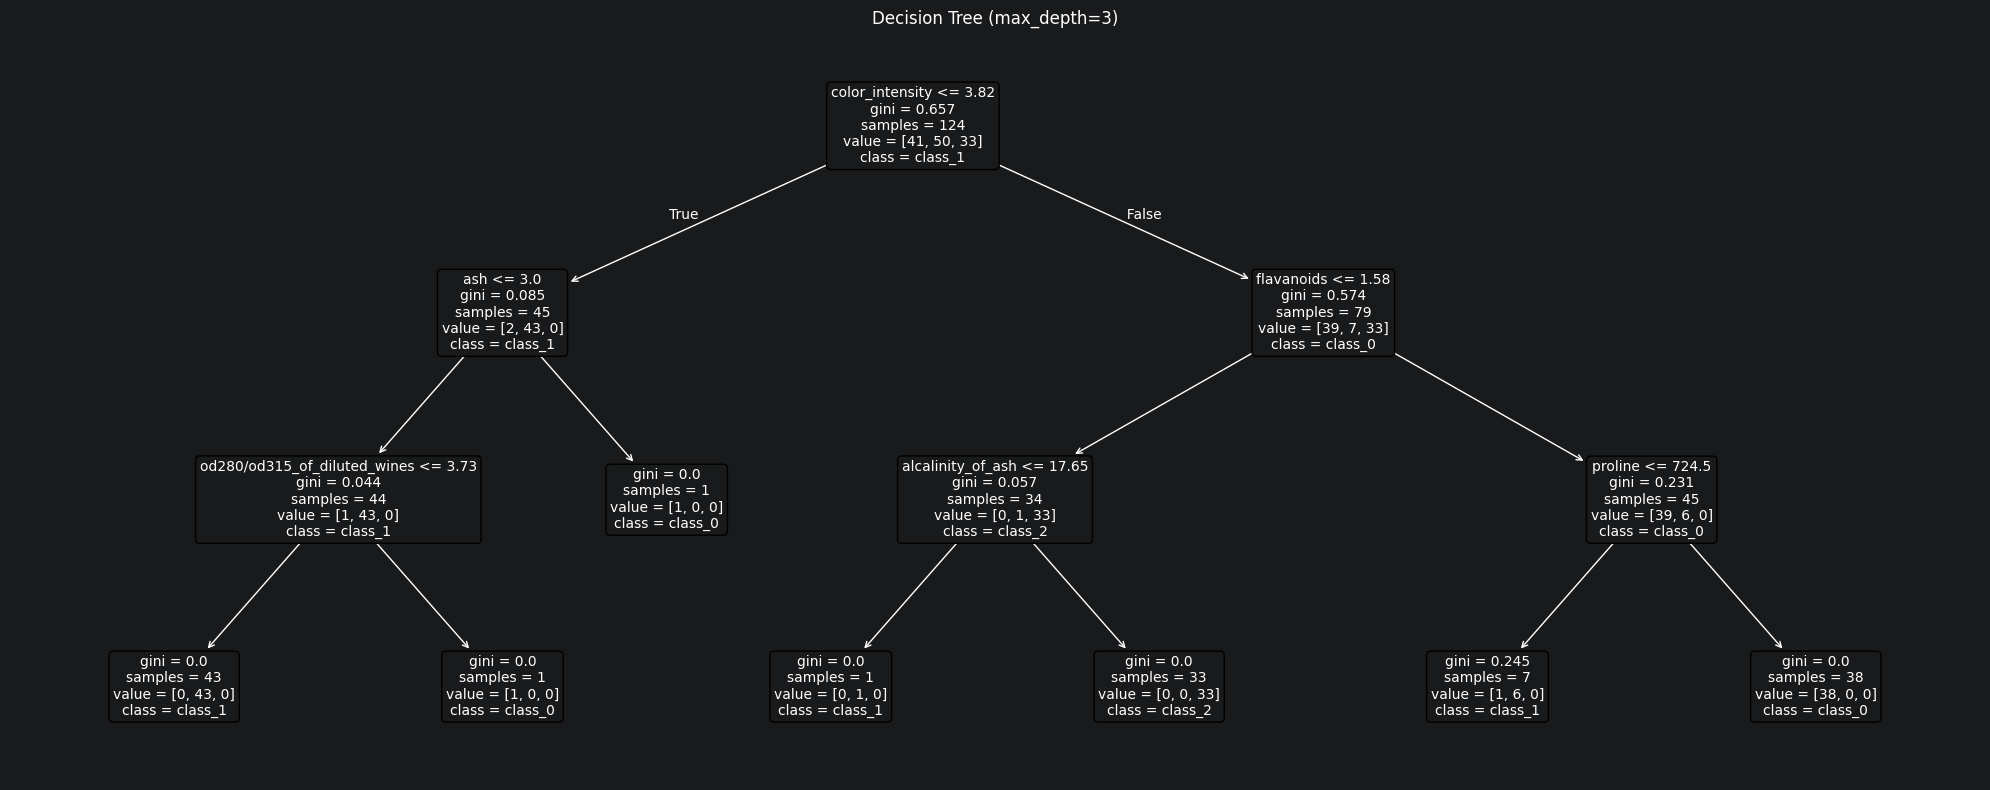

In [13]:
from sklearn.tree import plot_tree

clf_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_d3.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    clf_d3,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()

#An der wurtzel GINI = 0.67 = maximale aufteilung nach dem Split Gini 0.085 und 0.57 Information Gain ist also zumindest für den True fall sehr groß

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest trainieren
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Vergleich
acc_tree = accuracy_score(y_test, y_pred)        # Einzelbaum aus (b)
acc_rf   = accuracy_score(y_test, y_pred_rf)     # Random Forest
oob      = rf.oob_score_

print(f"Test-Accuracy Einzelbaum:  {acc_tree:.4f}")
print(f"Test-Accuracy Random Forest: {acc_rf:.4f}")
print(f"OOB-Score:                 {oob:.4f}")

Test-Accuracy Einzelbaum:  0.9630
Test-Accuracy Random Forest: 1.0000
OOB-Score:                 0.9758


---
## Daten für Aufgabe 3 — Synthetische 2D-Cluster

Vier sphärische Cluster für die Hauptaufgabe; ein zweiter Datensatz (`moons`) für die Diskussionsfrage.

# K-Means – Händische Berechnung

**Gegeben:** $X = \{1, 2, 3, 8, 9, 10, 25\}$, $K=2$, $\mu_1^{(0)} = 2$, $\mu_2^{(0)} = 9$

---

## Formeln

**Neuer Centroid:**
$$\mu_k = \frac{1}{|C_k|} \sum_{x \in C_k} x$$

**Zielfunktion:**
$$J = \sum_{k=1}^{K} \sum_{x \in C_k} (x - \mu_k)^2$$

---

## Iteration 1

Centroide: $\mu_1 = 2$, $\mu_2 = 9$

| $x$ | $\|x - \mu_1\|$ | $\|x - \mu_2\|$ | Cluster |
|:---:|:---:|:---:|:---:|
| 1  | 1  | 8  | C1 |
| 2  | 0  | 7  | C1 |
| 3  | 1  | 6  | C1 |
| 8  | 6  | 1  | C2 |
| 9  | 7  | 0  | C2 |
| 10 | 8  | 1  | C2 |
| 25 | 23 | 16 | C2 |

**Neue Centroide:**
$$\mu_1 = \frac{1+2+3}{3} = 2.0 \qquad \mu_2 = \frac{8+9+10+25}{4} = 13.0$$

**Zielfunktion:**
$$J = \underbrace{(1-2)^2+(2-2)^2+(3-2)^2}_{C_1} + \underbrace{(8-13)^2+(9-13)^2+(10-13)^2+(25-13)^2}_{C_2}$$
$$J = (1+0+1) + (25+16+9+144) = 2 + 194 = \mathbf{196}$$

---

## Iteration 2

Centroide: $\mu_1 = 2$, $\mu_2 = 13$

| $x$ | $\|x - \mu_1\|$ | $\|x - \mu_2\|$ | Cluster |
|:---:|:---:|:---:|:---:|
| 1  | 1  | 12 | C1 |
| 2  | 0  | 11 | C1 |
| 3  | 1  | 10 | C1 |
| 8  | 6  | 5  | C2 |
| 9  | 7  | 4  | C2 |
| 10 | 8  | 3  | C2 |
| 25 | 23 | 12 | C2 |

**Neue Centroide:**
$$\mu_1 = \frac{1+2+3}{3} = 2.0 \qquad \mu_2 = \frac{8+9+10+25}{4} = 13.0$$

**Zielfunktion:**
$$J = \underbrace{(1-2)^2+(2-2)^2+(3-2)^2}_{C_1} + \underbrace{(8-13)^2+(9-13)^2+(10-13)^2+(25-13)^2}_{C_2}$$
$$J = (1+0+1) + (25+16+9+144) = 2 + 194 = \mathbf{196}$$

---

## Konvergenz

| | Iteration 1 | Iteration 2 |
|---|:---:|:---:|
| $\mu_1$ | 2.0 | 2.0 |
| $\mu_2$ | 13.0 | 13.0 |
| $J$ | 196 | 196 |

Centroide und Zuordnungen sind nach Iteration 1 bereits stabil → **Algorithmus konvergiert.**
$J$ ist monoton gefallen.

---

## Beobachtung: Ausreißer $x = 25$

Der Punkt $x=25$ zieht $\mu_2$ von $9$ auf $13$ und repräsentiert damit die eigentliche Gruppe $\{8, 9, 10\}$ schlechter.
**Sichtbarer Nachteil:** K-Means ist empfindlich gegenüber Ausreißern, da quadratische Abstände deren Einfluss überproportional verstärken.

In [15]:

X_blobs, y_blobs_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

print(f'Blobs: {X_blobs.shape}')

Blobs: (300, 2)


Finale Trägheit (J): 564.91


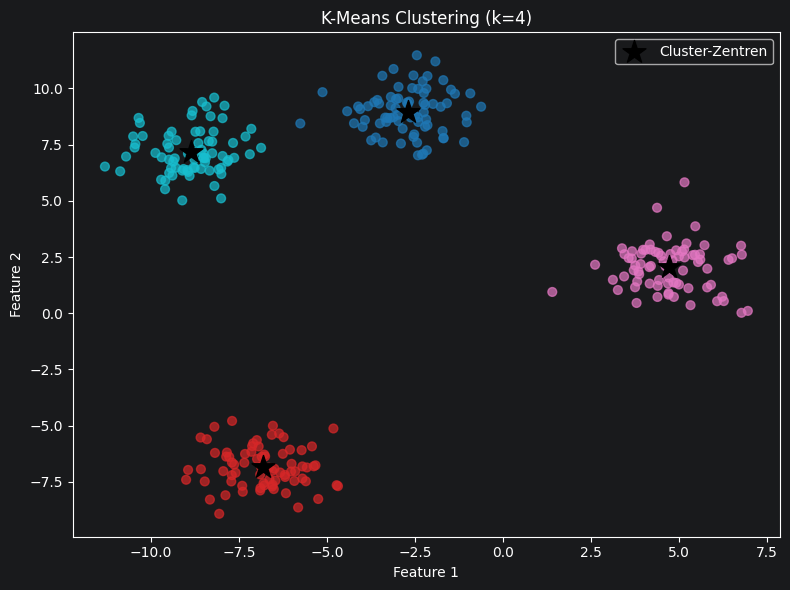

In [18]:
# K-Means anwenden
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(X_blobs)
labels  = kmeans.labels_
centers = kmeans.cluster_centers_

print(f'Finale Trägheit (J): {kmeans.inertia_:.2f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_blobs[:, 0], X_blobs[:, 1],
    c=labels, cmap='tab10', s=40, alpha=0.7
)
ax.scatter(
    centers[:, 0], centers[:, 1],
    c='black', marker='*', s=300, zorder=5, label='Cluster-Zentren'
)

ax.set_title('K-Means Clustering (k=4)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()

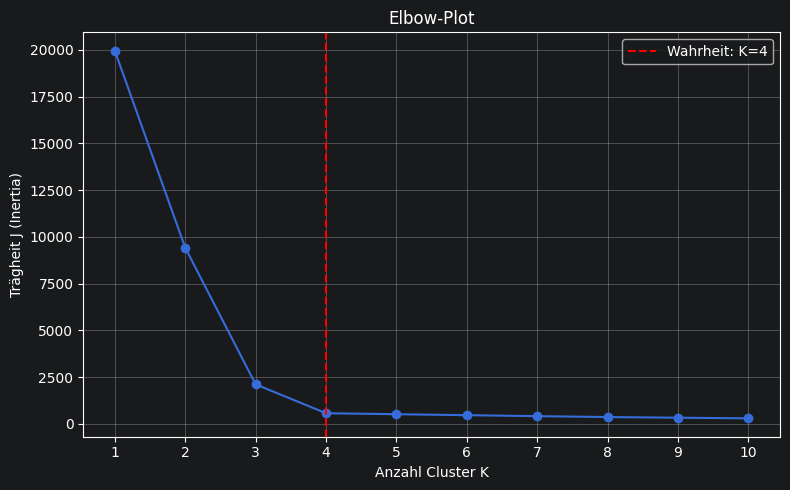

In [20]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.axvline(x=4, color='red', linestyle='--', label='Wahrheit: K=4')
plt.xlabel('Anzahl Cluster K')
plt.ylabel('Trägheit J (Inertia)')
plt.title('Elbow-Plot')
plt.xticks(K_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
results = []
for seed in range(5):
    km = KMeans(n_clusters=4, n_init=1, init='random', random_state=seed)
    km.fit(X_blobs)
    results.append({'random_state': seed, 'init': 'random', 'n_init': 1, 'J (Inertia)': round(km.inertia_, 2)})

# k-means++
km_default = KMeans(n_clusters=4, n_init=10, init='k-means++', random_state=42)
km_default.fit(X_blobs)
results.append({'random_state': 42, 'init': 'k-means++', 'n_init': 10, 'J (Inertia)': round(km_default.inertia_, 2)})

df_results = pd.DataFrame(results)
df_results

,random_state,init,n_init,J (Inertia)
0,0,random,1,564.91
1,1,random,1,8422.63
2,2,random,1,2062.05
3,3,random,1,2059.08
4,4,random,1,564.91
5,42,k-means++,10,564.91


## Aufgabe 3 — Ihre Lösung

In [ ]:
# Ihre Lösung Aufgabe 3


---
## Daten für Aufgabe 4 — Elliptische Cluster

Zwei 2D-Gauß-Verteilungen mit absichtlich verschiedenen Kovarianzstrukturen:
- Cluster 1 ist horizontal gestreckt
- Cluster 2 ist vertikal gestreckt

In [30]:
rng_ell = np.random.default_rng(seed=42)

mu1   = np.array([0.0, 0.0])
cov1  = np.array([[3.0, 0.0], [0.0, 0.5]])

mu2   = np.array([4.0, 4.0])
cov2  = np.array([[0.5, 0.0], [0.0, 3.0]])

X1 = rng_ell.multivariate_normal(mu1, cov1, size=200)
X2 = rng_ell.multivariate_normal(mu2, cov2, size=200)

X_ell = np.vstack([X1, X2])
y_ell_true = np.array([0]*200 + [1]*200)

print(f'Form: {X_ell.shape}')

Form: (400, 2)


## Aufgabe 4 — Ihre Lösung

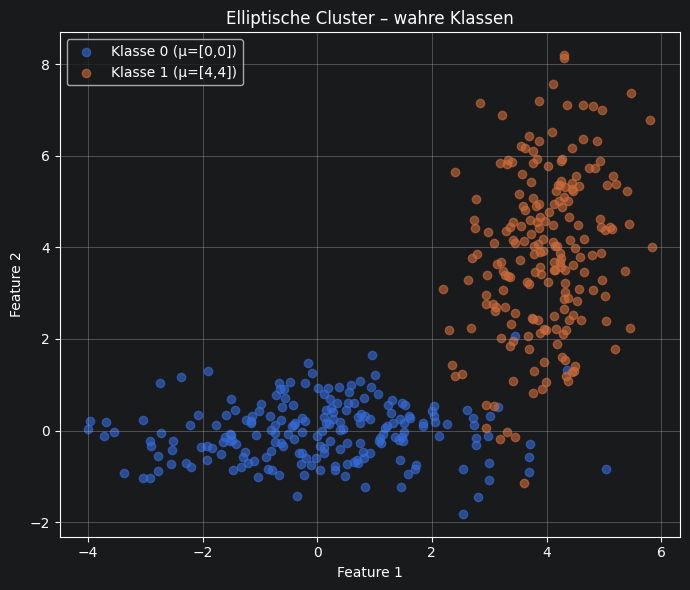

In [31]:
plt.figure(figsize=(7, 6))
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label='Klasse 0 (μ=[0,0])')
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.6, label='Klasse 1 (μ=[4,4])')
plt.title('Elliptische Cluster – wahre Klassen')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


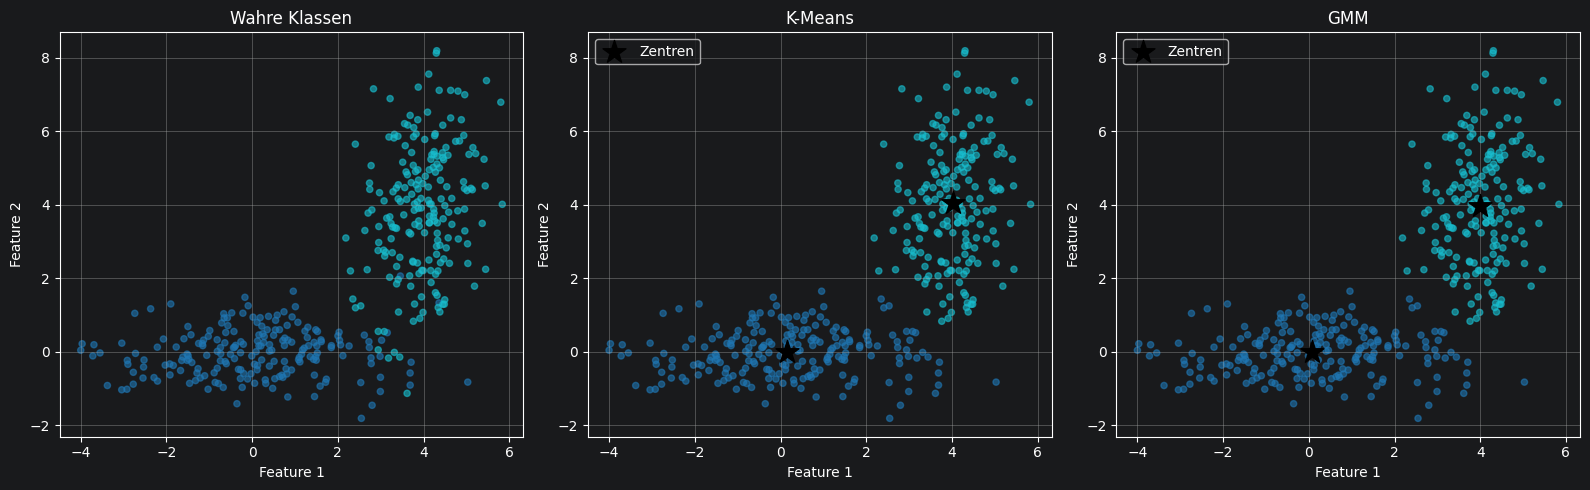

In [32]:
# Modelle trainieren
km  = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_ell)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42).fit(X_ell)

km_labels  = km.labels_
gmm_labels = gmm.predict(X_ell)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    (y_ell_true, None,                  'Wahre Klassen'),
    (km_labels,  km.cluster_centers_,   'K-Means'),
    (gmm_labels, gmm.means_,            'GMM'),
]

for ax, (labels, centers, title) in zip(axes, datasets):
    ax.scatter(X_ell[:, 0], X_ell[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='black', marker='*', s=300, zorder=5, label='Zentren')
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True)

plt.tight_layout()
plt.show()